# DATASET: Sleep Health and Lifestyle Dataset  
AIM: To build a multiple linear regression model predicting the stress level of a person with respect to quantitative features

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import dataset

data = pd.read_csv(r"C:\Users\gowri\Downloads\archive (1)\Sleep_health_and_lifestyle_dataset.csv")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Features: age,Sleep Duration,quality of Sleep,Physical Activity Level,Daily Steps,heart rate  
Label: Stress level

# Data Pre-processing

In [3]:
data.shape

(374, 13)

In [4]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [5]:
# Seems to have similar categories normal and normal weight
data['BMI Category'].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

In [6]:
# Replace'Normal' as 'Normal Weight' to avoid confusion
data['BMI Category']=data['BMI Category'].replace('Normal','Normal Weight')
data['BMI Category'].unique()

array(['Overweight', 'Normal Weight', 'Obese'], dtype=object)

In [7]:
data.dtypes 

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [9]:
# Binary encoding to covert categorical/object data to numerical data to enable analysis (since categorical features are ordinal and >5 features need to be encoded)
from category_encoders import BinaryEncoder

bi=BinaryEncoder()
data4=bi.fit_transform(data)
data4.head()

,Person ID,Gender_0,Gender_1,Age,Occupation_0,Occupation_1,Occupation_2,Occupation_3,Sleep Duration,Quality of Sleep,...,BMI Category_1,Blood Pressure_0,Blood Pressure_1,Blood Pressure_2,Blood Pressure_3,Blood Pressure_4,Heart Rate,Daily Steps,Sleep Disorder_0,Sleep Disorder_1
0,1,0,1,27,0,0,0,1,6.1,6,...,1,0,0,0,0,1,77,4200,1,1
1,2,0,1,28,0,0,1,0,6.2,6,...,0,0,0,0,1,0,75,10000,1,1
2,3,0,1,28,0,0,1,0,6.2,6,...,0,0,0,0,1,0,75,10000,1,1
3,4,0,1,28,0,0,1,1,5.9,4,...,1,0,0,0,1,1,85,3000,0,1
4,5,0,1,28,0,0,1,1,5.9,4,...,1,0,0,0,1,1,85,3000,0,1


In [10]:
# Check for categories in 'Sleep Disorder' column
data['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [11]:
# Use IterativeImputer after encoding to fill nulls in 'Sleep Disorder' column
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
itr= IterativeImputer(max_iter=10, random_state=0)
encodedata = itr.fit_transform(data4)

data5 = pd.DataFrame(encodedata, columns=data4.columns)

display(data5.head())

,Person ID,Gender_0,Gender_1,Age,Occupation_0,Occupation_1,Occupation_2,Occupation_3,Sleep Duration,Quality of Sleep,...,BMI Category_1,Blood Pressure_0,Blood Pressure_1,Blood Pressure_2,Blood Pressure_3,Blood Pressure_4,Heart Rate,Daily Steps,Sleep Disorder_0,Sleep Disorder_1
0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,6.1,6.0,...,1.0,0.0,0.0,0.0,0.0,1.0,77.0,4200.0,1.0,1.0
1,2.0,0.0,1.0,28.0,0.0,0.0,1.0,0.0,6.2,6.0,...,0.0,0.0,0.0,0.0,1.0,0.0,75.0,10000.0,1.0,1.0
2,3.0,0.0,1.0,28.0,0.0,0.0,1.0,0.0,6.2,6.0,...,0.0,0.0,0.0,0.0,1.0,0.0,75.0,10000.0,1.0,1.0
3,4.0,0.0,1.0,28.0,0.0,0.0,1.0,1.0,5.9,4.0,...,1.0,0.0,0.0,0.0,1.0,1.0,85.0,3000.0,0.0,1.0
4,5.0,0.0,1.0,28.0,0.0,0.0,1.0,1.0,5.9,4.0,...,1.0,0.0,0.0,0.0,1.0,1.0,85.0,3000.0,0.0,1.0


In [12]:
# Final check for nulls and dtype before proceeding to feature selection
data5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    float64
 1   Gender_0                 374 non-null    float64
 2   Gender_1                 374 non-null    float64
 3   Age                      374 non-null    float64
 4   Occupation_0             374 non-null    float64
 5   Occupation_1             374 non-null    float64
 6   Occupation_2             374 non-null    float64
 7   Occupation_3             374 non-null    float64
 8   Sleep Duration           374 non-null    float64
 9   Quality of Sleep         374 non-null    float64
 10  Physical Activity Level  374 non-null    float64
 11  Stress Level             374 non-null    float64
 12  BMI Category_0           374 non-null    float64
 13  BMI Category_1           374 non-null    float64
 14  Blood Pressure_0         3

# EDA

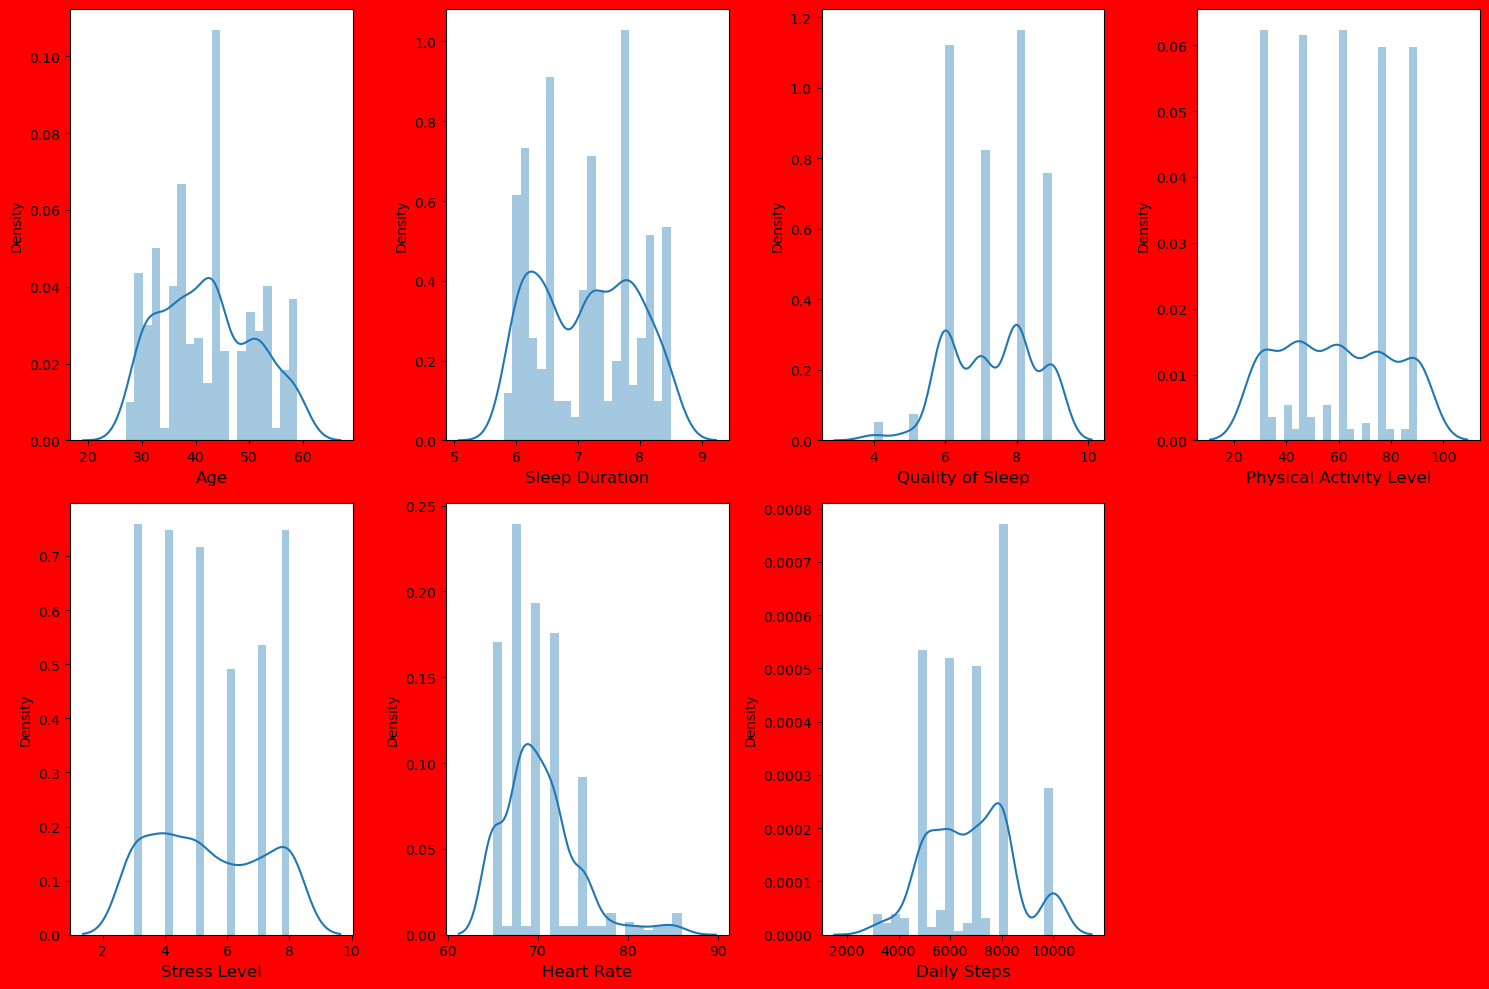

In [13]:
# Check data distribution for skewness (only numeric columns are given for checking skewness)
a = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']

plt.figure(figsize=(15, 10), facecolor='red')

plotnumber = 1
for column in a:
    if plotnumber <= 7:
        ax = plt.subplot(2, 4, plotnumber)
        sns.distplot(data[column], bins=20)
        plt.xlabel(column, fontsize=12)
    plotnumber += 1

plt.tight_layout()

1. The graph of "Physical Activity Level" appears to be positively skewed, meaning there are more people with 
low activity levels than high activity levels.  
2. The graph of "Stress Level" appears to be negatively skewed, meaning there are more people with low stress levels than high 
stress levels.  
3. The graph of "Sleep Duration" appears to be multimodal, meaning it has multiple peaks. This could be due to a number of 
factors, such as the fact that some people sleep in two shifts (e.g., a nap and a night's sleep).
4. Distribution of "Heart Rate" is approximately symmetrical.
5. Distribution of "Daily Steps" is approximately symmetrical.
6. Distribution of "Sleep Quality" is symmetrical. 
7. Distribution of "Age" is symmetrical.                                                                    

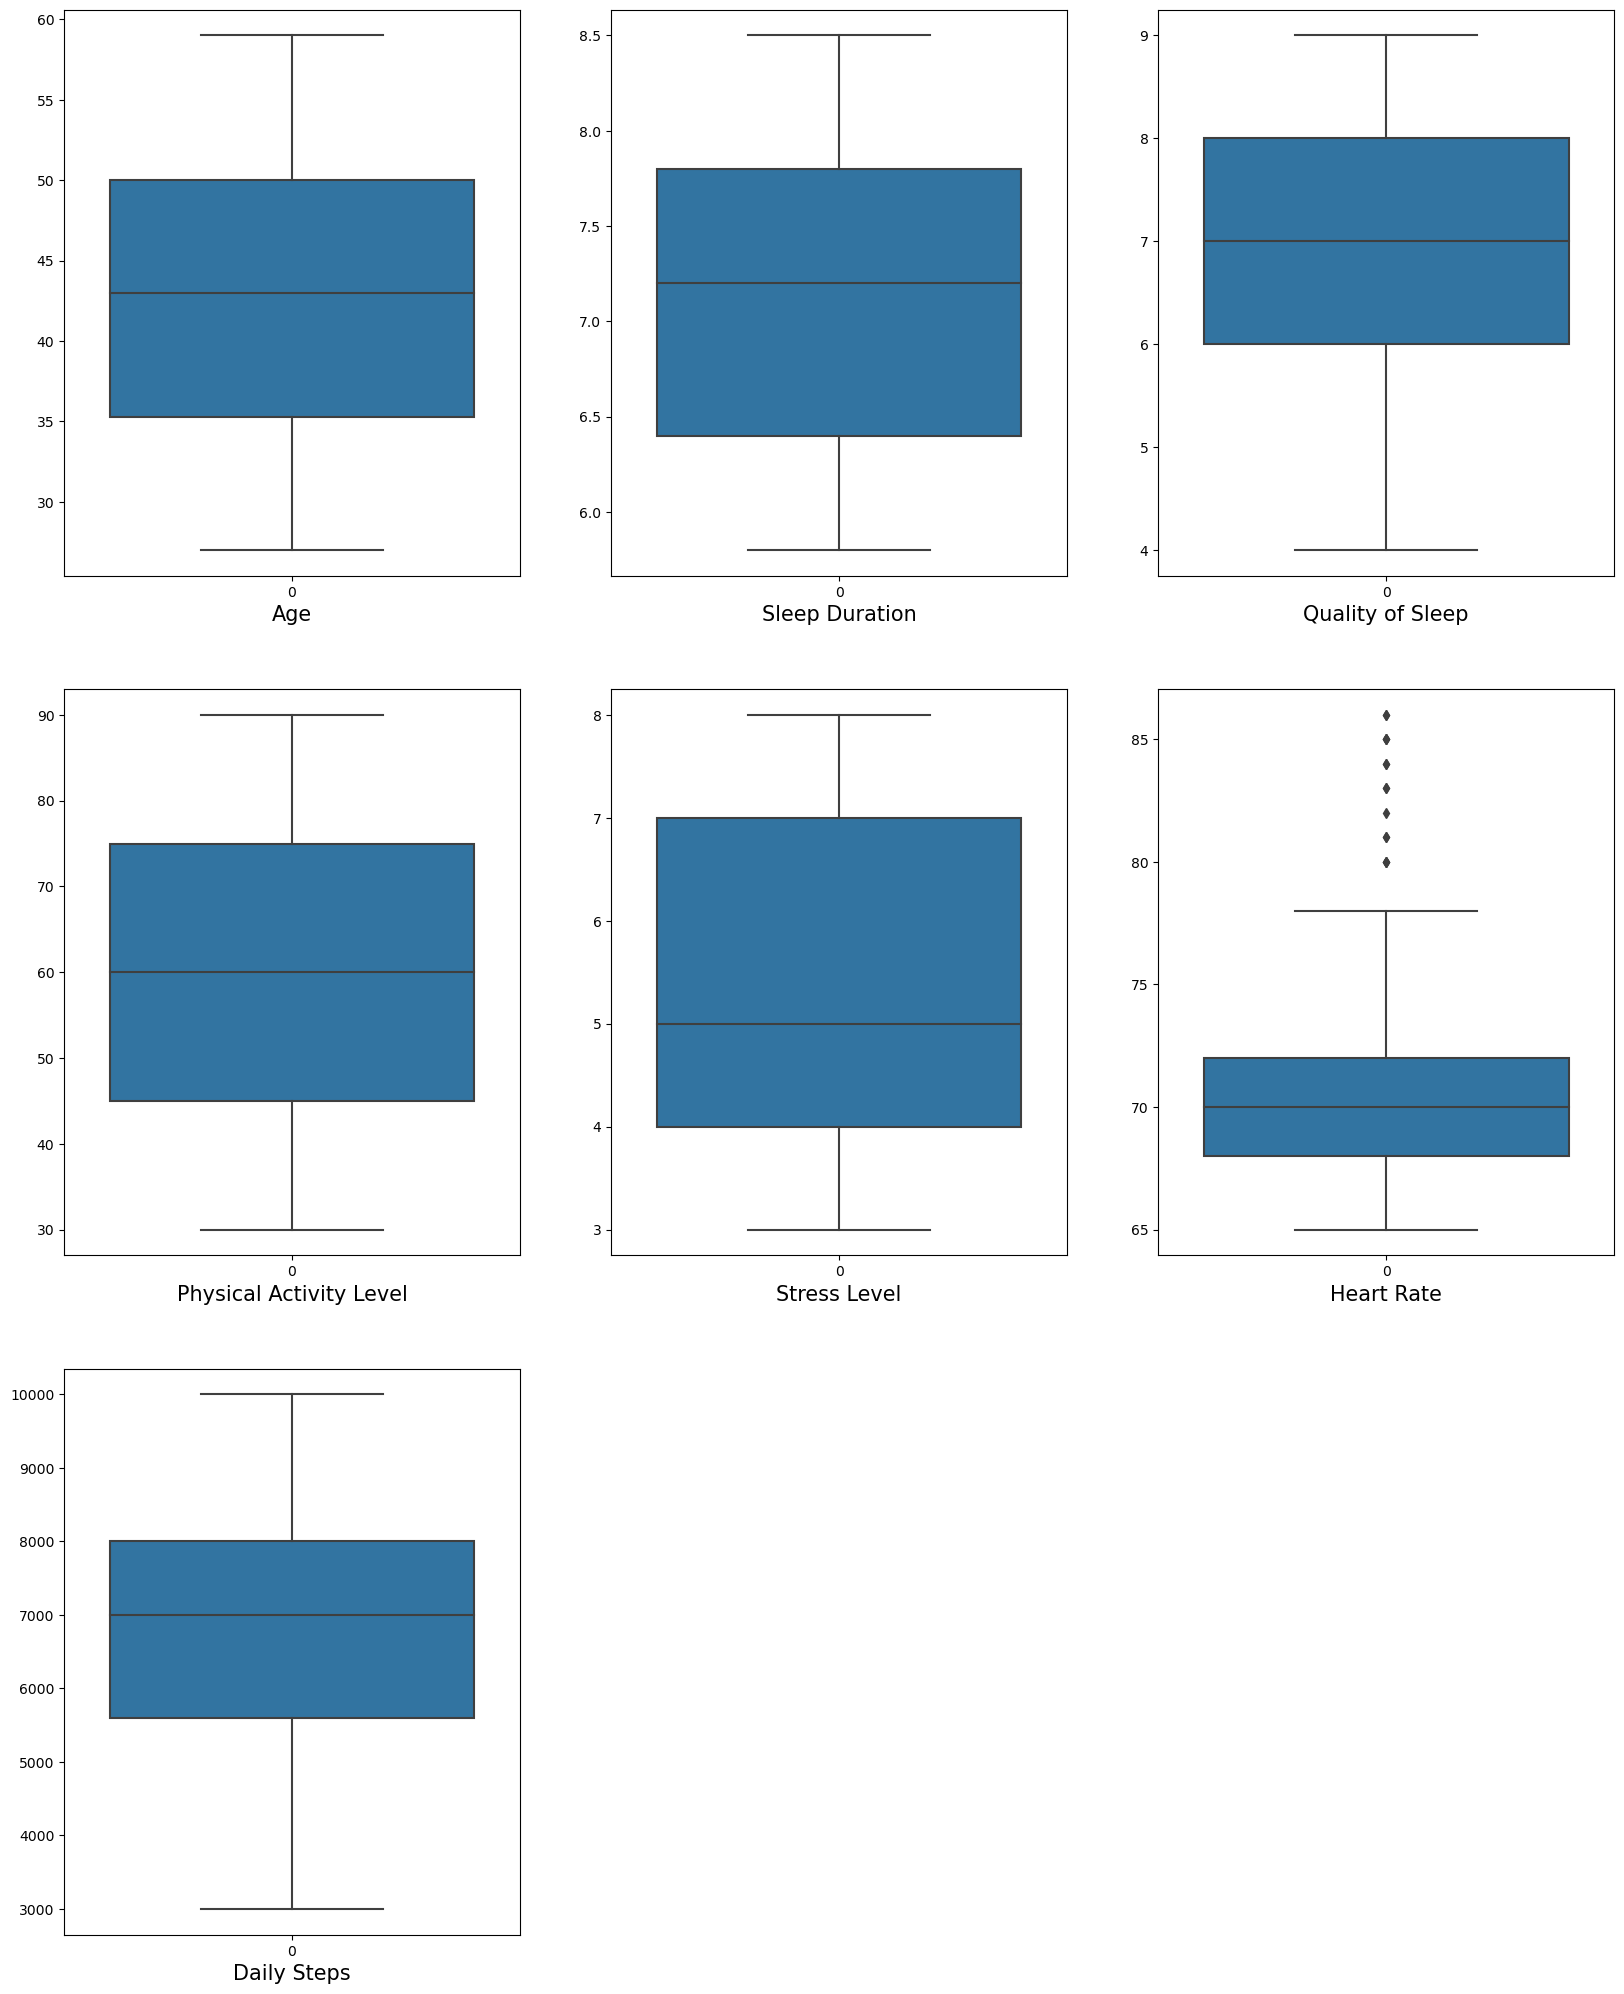

In [14]:
# Check boxplot for outliers
features=data[['Age','Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level','Heart Rate','Daily Steps']]
plt.figure(figsize=(20,25))
graph=1
for column in features:
    if graph<=7:
        plt.subplot(3,3,graph)
        ax=sns.boxplot(data=features[column])
        plt.xlabel(column, fontsize=15)
    graph+=1
plt.show()

There are higher outliers in heart rate

In [15]:
# Detect specific outliers using quantile method to see if the outlier is valid

if 'Heart Rate' in data.columns:
    q1 = data['Heart Rate'].quantile(0.25)
    q3 = data['Heart Rate'].quantile(0.75)

    iqr = q3 - q1

    # Calculate the upper bound for outliers
    high_hr = q3 + 1.5 * iqr

    print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, Upper bound for Heart Rate: {high_hr}")

else:
    print("The 'Heart Rate' column does not exist in the DataFrame.")

Q1: 68.0, Q3: 72.0, IQR: 4.0, Upper bound for Heart Rate: 78.0


The outlier is in normal range of heart rate. So we need not alter the data.

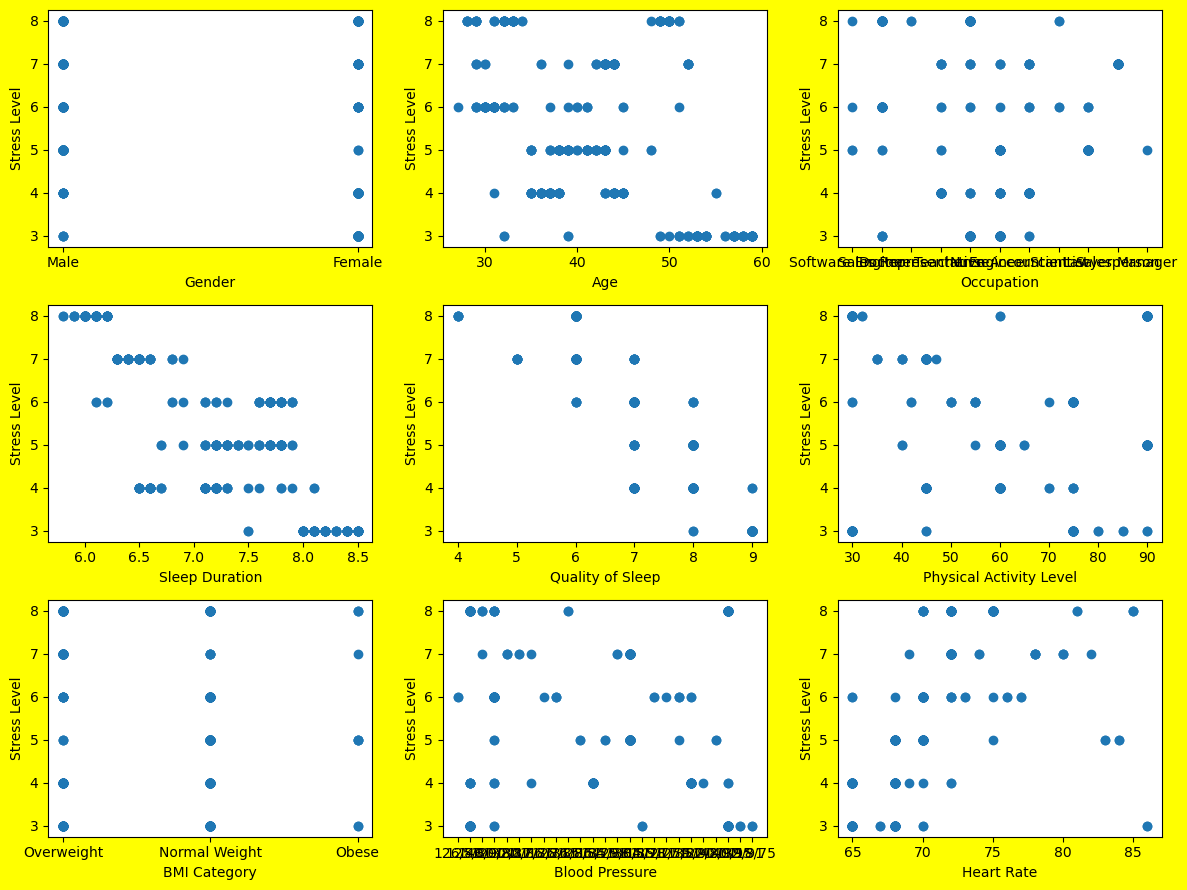

In [16]:
# Observe relationship between all features with respect to label
y=data['Stress Level']
x = data.drop(columns=['Stress Level', 'Person ID'], axis=1)
plt.figure(figsize=(12,9),facecolor='yellow')
plotnumber=1
for column in x:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        plt.scatter(x[column],y)
        plt.xlabel(column)
        plt.ylabel('Stress Level')
    plotnumber+=1
plt.tight_layout()

Insights:
    1. Stress level is almost the same in both genders  
    2. Stress level is high in young generation of around 30yrs of age  
    3. Stress level decreases with increase in sleep duration (linear relationship)  
    4. Stress level decreases with increase in quality of sleep (linear relationship)  
    5. Stress level decreases with increase in physical activity (linear relationship)  
    6. Stress level almost decreases with increase in blood pressure (linear relationship)  
    7. Stress level increase with increase in heart rate (linear relationship)  

<Figure size 1500x800 with 0 Axes>

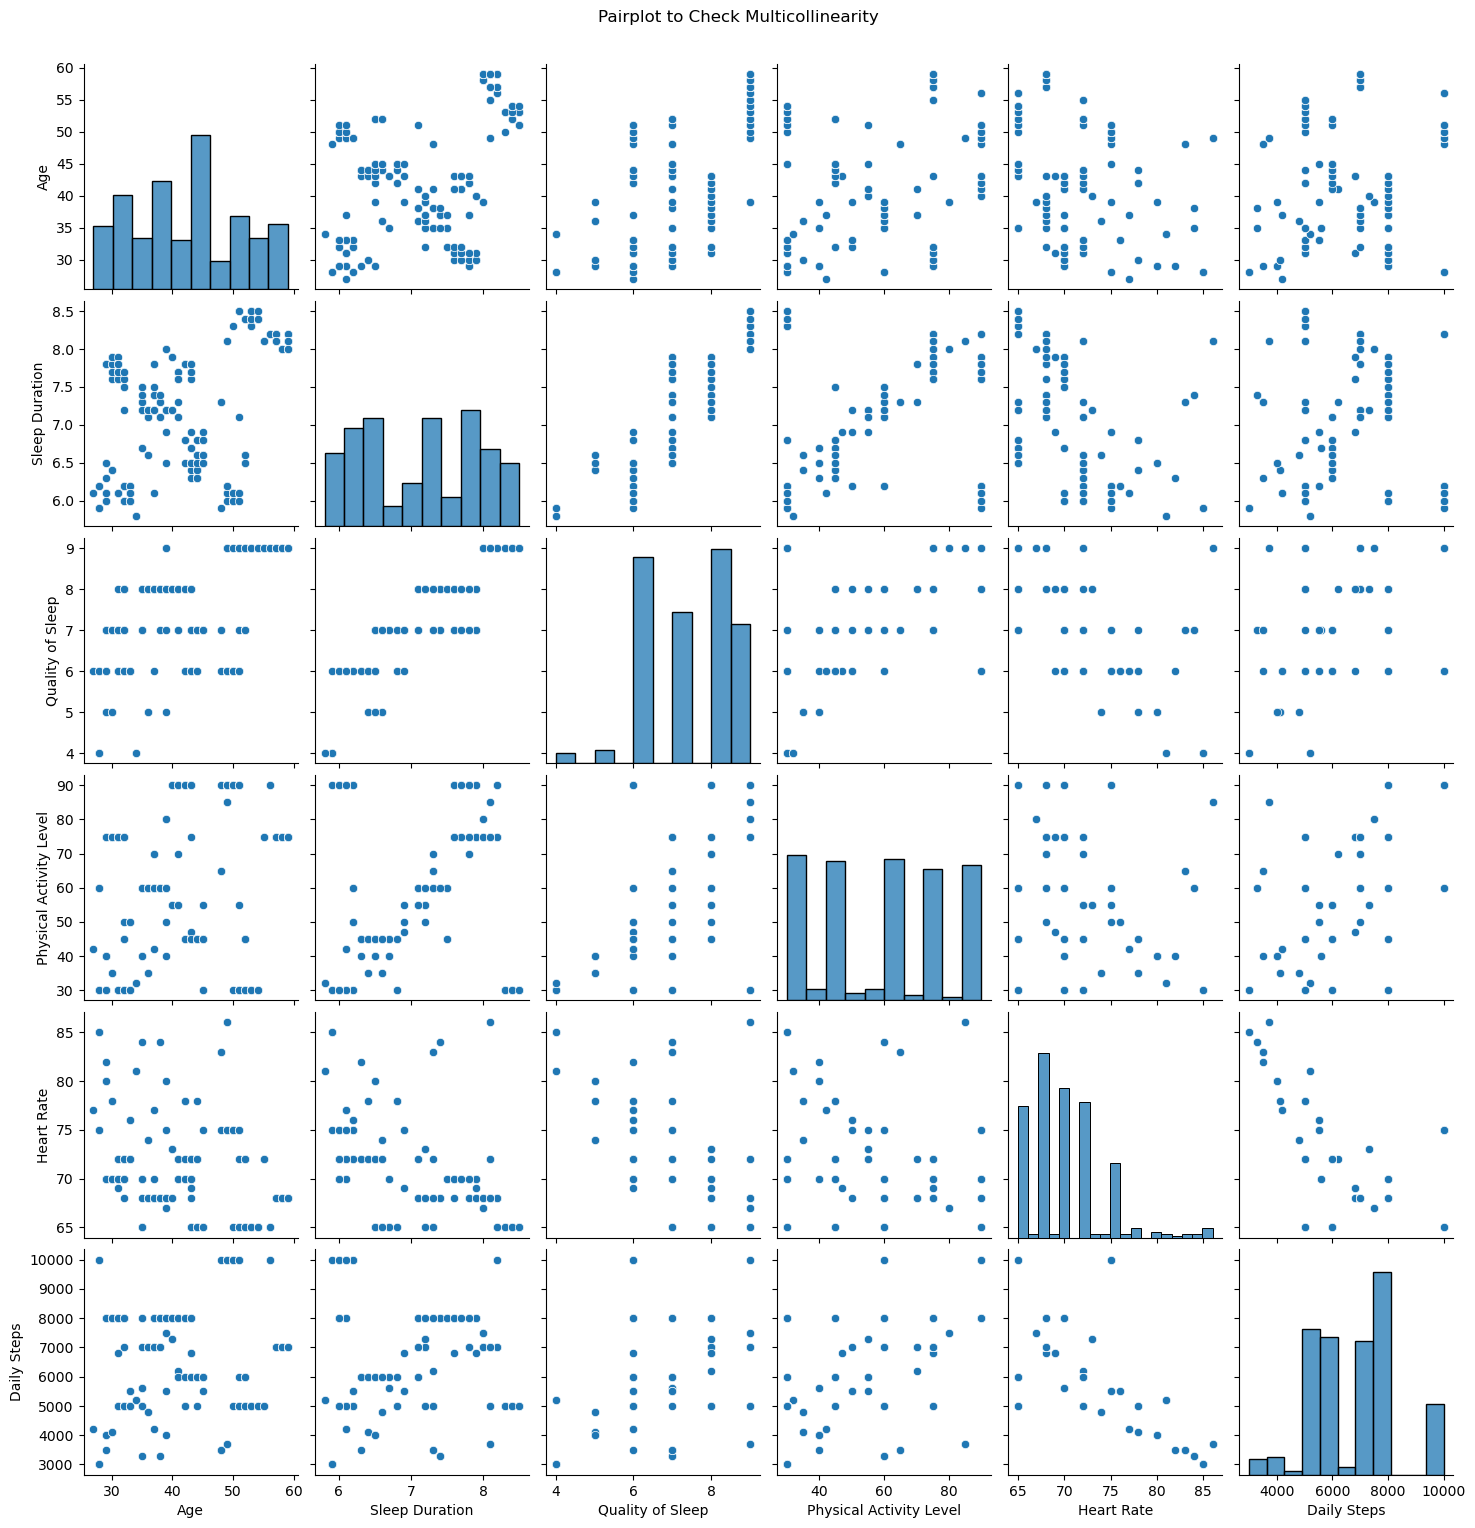

In [17]:
# Check for multicollinearity using pairplot (Find relationship between variables- Qualitative assessment)
x = data.drop(columns=['Stress Level','Person ID'], axis=1)

plt.figure(figsize=(15, 8))
sns.pairplot(x)
plt.suptitle("Pairplot to Check Multicollinearity", y=1.02)
plt.show()


There's linear relationship between quality of sleep and sleep duration

In [18]:
# Correlation matrix between selected features
correlation_matrix = data5[['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']].corr()

# Display the correlation matrix
correlation_matrix

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Age,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973
Sleep Duration,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533
Quality of Sleep,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791
Physical Activity Level,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723
Stress Level,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829
Heart Rate,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309
Daily Steps,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000


There's high positive correlation between quality of sleep and sleep duration, so either one can be eliminated to 
avoid multicollinearity.

In [19]:
# Check for multicollinearity using variance inflation factor (VIF) calculations.
x=data[['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_scaled, i) for i in range(x_scaled.shape[1])]
vif['Features'] = x.columns
vif

,VIF,Features
0,1.385041,Age
1,5.295312,Sleep Duration
2,11.000056,Quality of Sleep
3,5.007188,Physical Activity Level
4,7.952974,Stress Level
5,3.420481,Heart Rate
6,5.069089,Daily Steps


Here vif of quality of sleep is > 10 which can be considered as high, thereby showing high multicollinearity. 
So Quality of Sleep can be dropped and hence remove collinearity between the categorical features .

In [20]:
# Drop 'Quality of Sleep' column
data5.drop(columns='Quality of Sleep',axis=1,inplace=True)

In [21]:
# Feature Selection by analysing correlation matrix

print('\nFeature selection is the process of identifying and selecting a subset of input features that are most relevant to the target variable.\n')

corr= data5[['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']].corr()
corr


Feature selection is the process of identifying and selecting a subset of input features that are most relevant to the target variable.



,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Age,1.000000,0.344709,0.178993,-0.422344,-0.225606,0.057973
Sleep Duration,0.344709,1.000000,0.212360,-0.811023,-0.516455,-0.039533
Physical Activity Level,0.178993,0.212360,1.000000,-0.034134,0.136971,0.772723
Stress Level,-0.422344,-0.811023,-0.034134,1.000000,0.670026,0.186829
Heart Rate,-0.225606,-0.516455,0.136971,0.670026,1.000000,-0.030309
Daily Steps,0.057973,-0.039533,0.772723,0.186829,-0.030309,1.000000


In [22]:
# Confirm if the column is deleted from dataset
data5.head()

,Person ID,Gender_0,Gender_1,Age,Occupation_0,Occupation_1,Occupation_2,Occupation_3,Sleep Duration,Physical Activity Level,...,BMI Category_1,Blood Pressure_0,Blood Pressure_1,Blood Pressure_2,Blood Pressure_3,Blood Pressure_4,Heart Rate,Daily Steps,Sleep Disorder_0,Sleep Disorder_1
0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,6.1,42.0,...,1.0,0.0,0.0,0.0,0.0,1.0,77.0,4200.0,1.0,1.0
1,2.0,0.0,1.0,28.0,0.0,0.0,1.0,0.0,6.2,60.0,...,0.0,0.0,0.0,0.0,1.0,0.0,75.0,10000.0,1.0,1.0
2,3.0,0.0,1.0,28.0,0.0,0.0,1.0,0.0,6.2,60.0,...,0.0,0.0,0.0,0.0,1.0,0.0,75.0,10000.0,1.0,1.0
3,4.0,0.0,1.0,28.0,0.0,0.0,1.0,1.0,5.9,30.0,...,1.0,0.0,0.0,0.0,1.0,1.0,85.0,3000.0,0.0,1.0
4,5.0,0.0,1.0,28.0,0.0,0.0,1.0,1.0,5.9,30.0,...,1.0,0.0,0.0,0.0,1.0,1.0,85.0,3000.0,0.0,1.0


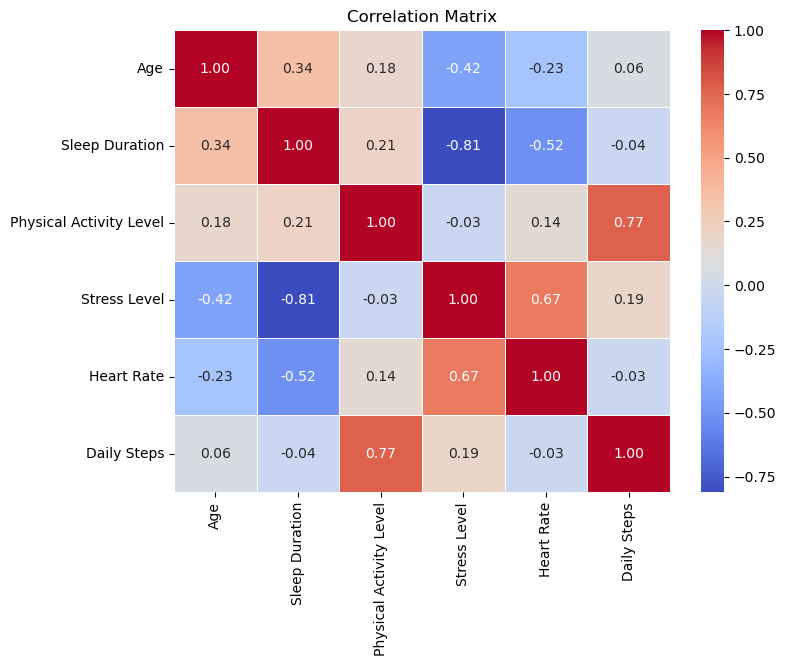

In [23]:
# Visual representation of the correlation matrix, you can use a heatmap with a library like Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

Selected features with high-moderate correlation: Sleep Duration(-), Heart rate(+) and Age(-)

In [24]:
data5.head()

,Person ID,Gender_0,Gender_1,Age,Occupation_0,Occupation_1,Occupation_2,Occupation_3,Sleep Duration,Physical Activity Level,...,BMI Category_1,Blood Pressure_0,Blood Pressure_1,Blood Pressure_2,Blood Pressure_3,Blood Pressure_4,Heart Rate,Daily Steps,Sleep Disorder_0,Sleep Disorder_1
0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,6.1,42.0,...,1.0,0.0,0.0,0.0,0.0,1.0,77.0,4200.0,1.0,1.0
1,2.0,0.0,1.0,28.0,0.0,0.0,1.0,0.0,6.2,60.0,...,0.0,0.0,0.0,0.0,1.0,0.0,75.0,10000.0,1.0,1.0
2,3.0,0.0,1.0,28.0,0.0,0.0,1.0,0.0,6.2,60.0,...,0.0,0.0,0.0,0.0,1.0,0.0,75.0,10000.0,1.0,1.0
3,4.0,0.0,1.0,28.0,0.0,0.0,1.0,1.0,5.9,30.0,...,1.0,0.0,0.0,0.0,1.0,1.0,85.0,3000.0,0.0,1.0
4,5.0,0.0,1.0,28.0,0.0,0.0,1.0,1.0,5.9,30.0,...,1.0,0.0,0.0,0.0,1.0,1.0,85.0,3000.0,0.0,1.0


In [25]:
data5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    float64
 1   Gender_0                 374 non-null    float64
 2   Gender_1                 374 non-null    float64
 3   Age                      374 non-null    float64
 4   Occupation_0             374 non-null    float64
 5   Occupation_1             374 non-null    float64
 6   Occupation_2             374 non-null    float64
 7   Occupation_3             374 non-null    float64
 8   Sleep Duration           374 non-null    float64
 9   Physical Activity Level  374 non-null    float64
 10  Stress Level             374 non-null    float64
 11  BMI Category_0           374 non-null    float64
 12  BMI Category_1           374 non-null    float64
 13  Blood Pressure_0         374 non-null    float64
 14  Blood Pressure_1         3

In [164]:
# Create new dataset with just the selected 5 features to be given as x in test_train set
data6=data5[['Sleep Duration','Heart Rate','Age']]
data6.describe()

,Sleep Duration,Heart Rate,Age
count,374.000000,374.000000,374.000000
mean,7.132086,70.165775,42.184492
std,0.795657,4.135676,8.673133
min,5.800000,65.000000,27.000000
25%,6.400000,68.000000,35.250000
50%,7.200000,70.000000,43.000000
75%,7.800000,72.000000,50.000000
max,8.500000,86.000000,59.000000


# Fitting Logistic Regression to the Training set & model building

In [26]:
# Model training and defining metrics function

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.25, random_state=2)

def metrics(model_name, a, b, c, d, train=True):
    if train:
        y_pred = model_name.predict(x_train)
        print('Accuracy of training = ', accuracy_score(y_train, y_pred))
    else:
        y_pred2 = model_name.predict(x_test)
        print('Accuracy of testing = ', accuracy_score(y_test, y_pred2))
        print('Classification report= ', classification_report(y_test, y_pred2, digits=2))

In [27]:
lr = LogisticRegression()
lr.fit(x_train, y_train)  

LogisticRegression()

In [28]:
print('Train', x_train.shape, y_train.shape)
print('Test', x_test.shape, y_test.shape)

Train (280, 7) (280,)
Test (94, 7) (94,)


# Test accuracy of the result

In [29]:
# Call the function and pass the dataset to check scores
metrics(lr,x_train,y_train,x_test,y_test,train=True) # Training score
metrics(lr,x_train,y_train,x_test,y_test,train=False) # Testing score

Accuracy of training =  0.95
Accuracy of testing =  0.9574468085106383
Classification report=                precision    recall  f1-score   support

           3       0.90      0.90      0.90        10
           4       0.95      0.95      0.95        20
           5       1.00      1.00      1.00        23
           6       1.00      0.80      0.89        10
           7       1.00      1.00      1.00        10
           8       0.91      1.00      0.95        21

    accuracy                           0.96        94
   macro avg       0.96      0.94      0.95        94
weighted avg       0.96      0.96      0.96        94



In [172]:
# Cross validation

from sklearn.model_selection import cross_val_score
cross_val_score(lr,x_scaled,y,cv=5).mean()

0.9141621621621623

Got 91.4%, therefore not overfitting

In [175]:
# Hyperparameter tuning
# To improve accuracy by GridSearchCV or RandomizedSearchCV

from sklearn.model_selection import GridSearchCV
# Define the parameter grid for logistic regression
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Instantiate GridSearchCV
gs = GridSearchCV(estimator=lr, param_grid=param_grid, scoring='accuracy', cv=5)

# Fit the model on training data
gs.fit(x_train, y_train)

# Print the best score and best parameters
print("Best Score:", gs.best_score_)
print("Best Parameters:", gs.best_params_)


Best Score: 0.975
Best Parameters: {'C': 1000, 'penalty': 'l2'}


Use the above parameters in the knn algorithm and check accuracy. Accuracy may/maynot improve after hyperparameter tuning.

In [183]:
lr = LogisticRegression(C=10, penalty='l2')
lr.fit(x_train, y_train)

LogisticRegression(C=10)

In [184]:
# Call the function and pass the dataset to check scores
metrics(lr,x_train,y_train,x_test,y_test,train=True) # Training score
metrics(lr,x_train,y_train,x_test,y_test,train=False) # Testing score

Accuracy of training =  0.9785714285714285
Accuracy of testing =  0.9680851063829787
Classification report=                precision    recall  f1-score   support

         3.0       0.91      1.00      0.95        10
         4.0       1.00      0.95      0.97        20
         5.0       1.00      1.00      1.00        23
         6.0       1.00      0.80      0.89        10
         7.0       0.83      1.00      0.91        10
         8.0       1.00      1.00      1.00        21

    accuracy                           0.97        94
   macro avg       0.96      0.96      0.95        94
weighted avg       0.97      0.97      0.97        94



Achieving an accuracy of 1.0 (100%) on your validation set after hyperparameter tuning might indicate potential issues or 
overfitting. Extremely high values for regularization strength (C) might lead to overfitting.
C=1000 and C=100 gave accuracy=1, therefore i used C=10